In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pickagm.distributions import ensemble_ks_bounds

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    calculate_gcim_distributions_for_sites,
)

from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import setup_AvgSA06_gcim_gm_selection

cfg = load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# AvgSA([0, 6])

In [ ]:
# set up the gcim / record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, _ = setup_AvgSA06_gcim_gm_selection()
percentiles = [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95]

In [9]:
# calculate the gcims
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06.pickle"

# calculate the gcims and save them
gcim_dists = calculate_gcim_distributions_for_sites(
    site_poe_disaggs, 
    disagg_stats, 
    site_model, 
    basic_selection_ctx,
    percentiles)

with open(gcim_dist_fp, "wb") as file:
    pickle.dump(gcim_dists, file)

Calculating GCIM Distributions:   0%|          | 0/360 [00:00<?, ?it/s]

In [5]:
gcim_dists[(0, 0.004988)]["cdfs"].keys()

dict_keys(['RSD595', 'PGA', 'IA', 'SA(0.025)', 'SA(0.033)', 'SA(0.045)', 'SA(0.059)', 'SA(0.079)', 'SA(0.106)', 'SA(0.141)', 'SA(0.188)', 'SA(0.251)', 'SA(0.335)', 'SA(0.447)', 'SA(0.597)', 'SA(0.797)', 'SA(1.063)', 'SA(1.418)', 'SA(1.893)', 'SA(2.525)', 'SA(3.37)', 'SA(4.497)', 'SA(6.0)'])

(0.0, 10.0)

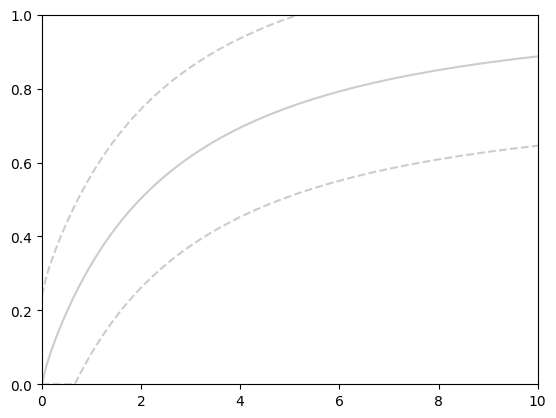

In [6]:
from phd_project.plotting.plotting import plot_conditional_distribution

target_cdfs = gcim_dists[(0, 0.0001)]["cdfs"]

ks_bounds = ensemble_ks_bounds(target_cdfs, 30, 0.05)

fig, ax = plt.subplots()
plot_conditional_distribution(ax, ks_bounds["IA"], with_ks_bounds=True, take_exp=False, take_log=False)
ax.set_xlim(0, 10)

In [7]:
ks_bounds["IA"]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.41703471e-01],
       [9.81192153e-04, 0.00000000e+00, 5.47406676e-06, 2.41708945e-01],
       [1.04313821e-03, 0.00000000e+00, 6.75580459e-06, 2.41710226e-01],
       [1.10899514e-03, 0.00000000e+00, 8.31511310e-06, 2.41711786e-01],
       [1.17900984e-03, 0.00000000e+00, 1.02067179e-05, 2.41713677e-01],
       [1.25344482e-03, 0.00000000e+00, 1.24949288e-05, 2.41715966e-01],
       [1.33257913e-03, 0.00000000e+00, 1.52550667e-05, 2.41718726e-01],
       [1.41670947e-03, 0.00000000e+00, 1.85750544e-05, 2.41722046e-01],
       [1.50615124e-03, 0.00000000e+00, 2.25571810e-05, 2.41726028e-01],
       [1.60123979e-03, 0.00000000e+00, 2.73200492e-05, 2.41730791e-01],
       [1.70233160e-03, 0.00000000e+00, 3.30007123e-05, 2.41736471e-01],
       [1.80980569e-03, 0.00000000e+00, 3.97570077e-05, 2.41743228e-01],
       [1.92406499e-03, 0.00000000e+00, 4.77700897e-05, 2.41751241e-01],
       [2.04553788e-03, 0.00000000e+00, 5.72471628e